In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest

# Угрозы внешней достоверности

Основные типы ошибок и угроз, которые могут возникнуть в ходе экспериментов - это **угрозы внутренней достоверности** (возникают внутри механик проведения экспериментов - нарушение правил SUTVA, ошибка выжившего, SRM, проблема выборочного/вынужденного воздействия) и **угрозы внешней достоверности** (возникают при переносе полученных выводов на генеральную совокупность или новый сегмент). Кроме этих угроз существуют и **другие проблемы**: влияние подглядывания и непрерывный мониторинг метрик, ошибка множественных сравнений, парадокс Симпсона, эффект обучения, долговременный эффект от нововведения и неправильное окно конверсии нововведения

Рассмотрим подробнее угрозы внешней достоверности.

Внешняя достоверность (external validity) характеризует пределы, в которых можно обобщать или использовать зависимости, полученные в ходе эксперимента.

**Виды угроз внешней достоверности**

- Эффект сопротивления новому (primacy effect)
- Эффект новизны (novelty effect)
- Эффект влияния среды


Внешняя достоверность отражает степень, с которой результаты контролируемого эксперимента могут быть обобщены и экстраполированы на будущие периоды, новые области применения, другие популяции или сегменты.

# Эффект сопротивления новому


Эффект сопротивления новому по-другому называется Primacy Effect или Change Aversion. Из-за когнитивных искажений человек может больше доверять той информации, которую узнал первой. Поэтому опытные пользователи могут относиться с негативом к новому дизайну, ведь они уже привыкли к старому, даже менее оптимальному.

**Суть эффекта:**
опытным пользователям может потребоваться время для принятия изменений, чтобы отказаться от привычного алгоритма действий;
необходимость переучиваться может привести к неприятию нововведения.
Последствия - рост ошибки II рода

**Способы выявлять эффект сопротивления новому:**

1. Разбить трафик в эксперименте на опытных и на новых пользователей и смотреть эффект для нововведения отдельно для каждой группы. Построить для них график эффекта воздействия с течением времени. Если присутствует эффект сопротивления новому, то группа «старых» пользователей выглядит в начале теста хуже, чем эффект на «новых» пользователях. Со временем это различие пропадает.

2. Применять детекцию с помощью ML и анализа временных рядов. Для обучения можно использовать исторические данные - как изменялась разница между старыми и новыми пользователями.

Эффект сопротивления новому наблюдается в случае внедрения серьезных изменений в продукте, которые сильно изменяют привычный пользовательский путь или привычный алгоритм действий. Если такое присутствует необходимо удлинить тест и сегментировать пользователей на новых и опытных для проверки гипотезы на присутствие эффектов новизны или сопротивления новому

# Эффект новизны

Эффект новизны, или Novelty Effect, проявляется, когда пользователи с бОльшим интересом реагируют на нововведения, но ажиотаж имеет временный характер.

**Суть эффекта:**

- Люди с интересом реагируют на новые функции или дизайн в продукте
- Новая функция привлекает внимание пользователей, что отражается в увеличении метрик в первые дни
- Механики, рассчитанные на кратковременный эффект роста, резко повышают метрику, а затем она возвращается к обычному эффекту
- Складывается ощущение, что нововведение положительно воспринято пользователями
- Если пользователи не увидят в новом функционале пользы, то с течением времени метрики снизятся, что покажет истинное отношение к нововведению

**Последствия**:
Увеличение вероятности ошибки I рода и переоценка роли нововведения

**Пример проявления эффекта новизны**: команда нотификации начинает использовать эмоджи при отправке сообщений, что в первые дни может вызвать повышенный интерес у старых пользователей. У новых пользователей нет сформированных ожиданий, поэтому картина по ним будет более объективная.

**Какие эксперименты наиболее предрасположены к эффекту новизны**:
- значительные изменения, где пользователи активно изучают новые функции в первые дни
- эксперименты с уведомлениями
- рекомендации на основе алгоритмов с ограниченным пулом кандидатов (друзья, обновления, люди, которых вы можете знать)

**Как выявлять эффект новизны**

1. Построить общий график эффекта от использования нового функционала во времени (дельта-график)
Если присутствует эффект новизны, то со временем эффект от нововведения снизится. При этом эффект по дням может быть разным: резко меняться вначале и в течение нескольких дней возвращаться к обычному значению, либо может меняться постепенно. По сути это проверка, стабилен эффект или нет. Проблема отслеживания изменения эффекта во времени в том, что результат можно будет увидеть только в конце эксперимента.

2. Тест Фуллера на проверку стационарности
3. Алгоритм от LinkedIn для детекции эффекта новизны, предложенный LinkedIn. Они написали линейную модель, описывающую тренд

$$
\Delta\%^{[t,t]} = \beta_0 + \beta_1 \cdot \frac{1}{t^{\alpha}} + \beta_2 \cdot \frac{1}{t^{\gamma}}
$$

$t$ - номер дня в эксперименте

$\beta_0, \beta_1, \beta_2$ - коэффициенты линейной модели, апроксимирующей разницу между реальными и прогнозными данными

$\alpha$ - степенной коэффициент для медленно снижающегося тренда

$\gamma$ - степенной коэффициент для быстро снижающегося тренда

Для своей модели LinkedIn опытным путем основе большого числа экспериментов подобрали степенные коэффициенты: $\alpha = 0.35$ и $\gamma = 2$

Эффект новизны присутствует, если удовлетворяются следующие условия:
1. Линейная модель хорошо описывает тренд однодневного эффекта, т.е. относительное отклонение реальных данных от прогнозных из калибровочного уравнения оценивается по значению R2. Чем выше R2, тем точнее наши данные совпадают с формой калибровочного уравнения, которое изначально описывает эффект новизны (R-квадрат ≥0,8).
2. fitted линия (модель прогноза, которую строит линейная функция) монотонно изменяется со временем.
3. Наибольший однодневный вклад статистически значимо отличается от наименьшего.
Подробности про алгоритм от LinkedIn [здесь](https://arxiv.org/ftp/arxiv/papers/1808/1808.00114.pdf)

# Эффект влияния среды


Эффект влияния среды ― это влияние внешних событий, трендов на результаты эксперимента. Например, праздники и погода, технические неисправности оборудования, день недели и время суток, сезонность

**Как снизить эффект влияния среды**:

- Стараться не проводить тесты в период, когда есть риск, что поведение пользователей будет отличаться от обычного
- При планировании теста обращать внимание на будущие события

Если все-таки тест необходим, при экстраполяции его результатов учитывать возможное смещение из-за эффекта влияния среды

# Как обходить эффекты сопротивления новому и новизны


Эффекты сопротивления новому и новизны важно учитывать для:
- предотвращения переоценивания или недооценивания влияния от нововведения
- принятия взвешенного решения с точки зрения понимания долгосрочных изменений в ключевых метриках
- снижения возможной неудовлетворенности пользователей, даже если ключевые метрики растут


**Как обходить эти эффекты:**

1. Оба эффекта кратковременные, поэтому можно удлинить тест, чтобы сгладить влияние обоих эффектов. Стоит по историческим данным определить, сколько времени в вашем продукте идет привыкание к новизне.
2. Оставить в тесте только новых пользователей, которые впервые сталкиваются с продуктом, тем самым одновременно исключив влияние эффектов. Есть ограничение: если в вашем продукте велика когорта старых пользователей, то учитывать только условные 10% новичков будет не самой хорошей практикой.
3. Сегментировать эффект от нововведения по различным дням или различным пользовательским посещениям, чтобы понять, изменяется ли эффект со временем.
Исключить первую неделю или две для стабилизации разницы между метриками эффекта в экспериментальных группах.

4. Применить временнЫе техники:
- Даты проведения эксперимента. Обычно значения метрик достигают пика в первые несколько дней, а затем падают. Сравнивая изменения метриках в разные даты, можно проверить сигналы к присутствию эффекта новизны.

- День/неделя с момента первого посещения. Начиная с первого дня эксперимента, для каждого пользователя разделите оставшиеся дни на «n» равных сегментов. Сравните, как изменяются метрики между сегментами от начала эксперимента к концу.

- Первая vs вторая часть эксперимента. Для каждого пользователя время в эксперименте разделяется на две части. Проверяется, изменяются ли метрики в каждом интервале. Можно для каждого пользователя проводить парный t-test, сравнивая его поведение в первой и во второй части эксперимента.

# Практика на синтетических данных

## Эффект сопротивления новому

Посмотрим, как ведет себя на графике эффект сопротивления новому.

### Исходные данные

Таблица представляет из себя агрегированные данные, в которых для каждого активного пользователя (`user_id`) на каждого пользователя указано общее количество просмотров объявлений за день (`total_view_ads`) и дата просмотра (`view_ad_date`), а также дата первого визита пользователя в приложение (`first_date_in_app`). Факт конверсии в просмотр закодирован в бинарную метрику `crt_to_view_ad`. Также все пользователи размечены на новых и старых (`user_status`), и на 2 группы для проведения эксперимента А1 контрольная и А2 тестовая (`sample_type`)

В первую очередь мы рассчитаем порядковый номер дня проведения эксперимента, и перемаркируем для наглядности метки A1->A и A2->B. Также обнаружилось, что часть данных не доехала до нас - потерян кусочек данных для старых пользователей за 4 дня. Поскольку данные нам нужны для симуляции - поставим заплатку из известных данных

Далее попробуем проиллюстрировать, как оличается динамика метрики в случае, когда эффекта сопротивления новому нет, и когда он есть, с помощью графиков самих метрик по сегментам, и с помощью дельта-графиков. Сам эффект новизны мы зададим искусственно с помощью функции гиперболы

In [2]:
df = pd.read_csv('data_for_primacy effect_1.csv')
df

,first_date_in_app,date_in_app,view_ad_date,user_id,user_status,total_view_ads,crt_to_view_ad,sample_type
0,2023-08-01,2023-08-01,2023-08-01,AAAXbgPR+ee/xGqljT6kpXs/PaY=,new,3,1,A1
1,2023-08-01,2023-08-02,2023-08-02,AAAXbgPR+ee/xGqljT6kpXs/PaY=,new,3,1,A1
2,2023-08-01,2023-08-03,NaN,AAAXbgPR+ee/xGqljT6kpXs/PaY=,new,0,0,A1
3,2023-08-01,2023-08-04,NaN,AAAXbgPR+ee/xGqljT6kpXs/PaY=,new,0,0,A1
4,2023-08-01,2023-08-05,2023-08-05,AAAXbgPR+ee/xGqljT6kpXs/PaY=,old,1,1,A1
...,...,...,...,...,...,...,...,...
6209134,2023-08-02,2023-08-20,2023-08-20,7IL0LMVDihGRznnOY9y7u+p2qmk=,old,24,1,A2
6209135,2023-08-02,2023-08-22,2023-08-22,7IL0LMVDihGRznnOY9y7u+p2qmk=,old,5,1,A2
6209136,2023-08-02,2023-08-02,2023-08-02,7IMZ+JrS/w0hdEJd/H9bE1wmLIc=,new,1,1,A1
6209137,2023-08-02,2023-08-03,NaN,7IMZ+JrS/w0hdEJd/H9bE1wmLIc=,new,0,0,A1


In [3]:
# Меняем типизацию для дат
df = df.assign(first_date_in_app	 = pd.to_datetime(df.first_date_in_app), date_in_app = pd.to_datetime(df.date_in_app),	view_ad_date = pd.to_datetime(df.view_ad_date))

# Добавляем день проведения теста
test_days = pd.DataFrame({'date_in_app': pd.date_range(df.date_in_app.min(), df.date_in_app.max()), 'day_of_test': np.arange(1, len(pd.date_range(df.date_in_app.min(), df.date_in_app.max()))+1)})
df = df.merge(test_days, on='date_in_app')

# Переобозначаем принадлежность к группе
df['sample'] = np.where(df['sample_type'] == 'A1', 'A', 'B')
df = df.drop('sample_type', axis=1)


# У старых пользователей не хватает записей с 1 по 4 августа
# np.polyfit(x=np.arange(5, 10), y=[123000, 163000, 197500, 205000, 211000], deg=1) # -> array([21800., 27300.]) динамика кол-ва пользователей с 5 по 10 день
patch_flow = pd.DataFrame({"day_of_test": np.arange(1, 5), "sample_size": (np.arange(1,5)*21800+27300)*1.05, "new_date": pd.to_datetime(pd.date_range("2023-08-01", "2023-08-04"))})

patch = pd.DataFrame()
for i in range(len(patch_flow)):
    day_of_test, sample_size, new_date = patch_flow.day_of_test[i], patch_flow.sample_size[i], patch_flow.new_date[i]
    sample = df.query('user_status=="old"&first_date_in_app=="2023-08-01"').drop_duplicates('user_id').sample(int(sample_size)).reset_index(drop=True)\
            .assign(date_in_app = new_date, day_of_test = day_of_test, view_ad_date = lambda df: np.where(df.view_ad_date==df.view_ad_date, new_date, df.view_ad_date))
    patch = pd.concat([patch, sample]).reset_index(drop=True)

df = pd.concat([patch, df]).reset_index(drop=True)
df

<ipython-input-3-562757445>:20: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  sample = df.query('user_status=="old"&first_date_in_app=="2023-08-01"').drop_duplicates('user_id').sample(int(sample_size)).reset_index(drop=True)\
<ipython-input-3-562757445>:20: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  sample = df.query('user_status=="old"&first_date_in_app=="2023-08-01"').drop_duplicates('user_id').sample(int(sample_size)).reset_index(drop=True)\
<ipython-input-3-562757445>:20: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) i

,first_date_in_app,date_in_app,view_ad_date,user_id,user_status,total_view_ads,crt_to_view_ad,day_of_test,sample
0,2023-08-01,2023-08-01,2023-08-01,qPc9vxXw2N5gt/5cYmvveel5/yI=,old,14,1,1,A
1,2023-08-01,2023-08-01,2023-08-01,WVAkTjXnVouX5Wpi5ZdxA3sMMU8=,old,13,1,1,B
2,2023-08-01,2023-08-01,2023-08-01,q7x7jZe8kZr91qjE2VoG5EAlz9g=,old,4,1,1,B
3,2023-08-01,2023-08-01,2023-08-01,DPyg9nRZvqX5ZhKJg9FnLYgMFUo=,old,2,1,1,B
4,2023-08-01,2023-08-01,2023-08-01,TiaCmyLD0IfrOf6DgpAu+wJDrgM=,old,9,1,1,A
...,...,...,...,...,...,...,...,...,...
6552694,2023-08-02,2023-08-20,2023-08-20,7IL0LMVDihGRznnOY9y7u+p2qmk=,old,24,1,20,B
6552695,2023-08-02,2023-08-22,2023-08-22,7IL0LMVDihGRznnOY9y7u+p2qmk=,old,5,1,22,B
6552696,2023-08-02,2023-08-02,2023-08-02,7IMZ+JrS/w0hdEJd/H9bE1wmLIc=,new,1,1,2,A
6552697,2023-08-02,2023-08-03,NaT,7IMZ+JrS/w0hdEJd/H9bE1wmLIc=,new,0,0,3,A


In [ ]:
df.pivot_table(index='user_status', columns='sample', values='user_id', aggfunc='nunique')

sample,A,B
user_status,,
new,482932,481455
old,334752,334002


In [ ]:
df.groupby('user_status', as_index=False).agg({'day_of_test':['max','min']})

user_status day_of_test    
                      max min
0         new          24   1
1         old          24   1

In [4]:
# Убеждаемся, что кол-во записей соответствует кол-ву дней входа в приложение. пользователи не каждый день входят в приложение
df_agg = df.groupby(['user_id','sample'], as_index=False).agg(mean_crt_to_view_ad = ('crt_to_view_ad','mean'), first_date_in_app	= ('first_date_in_app', 'min'), min_date_in_app = ('date_in_app','min'),
                                                                   max_date_in_app = ('date_in_app','max'), count_records = ('date_in_app','count'))\
                .assign(count_days = lambda df: (df.max_date_in_app-df.min_date_in_app).dt.days)

df_agg

,user_id,sample,mean_crt_to_view_ad,first_date_in_app,min_date_in_app,max_date_in_app,count_records,count_days
0,+++2nGjWtey7NgkhMNqSoPHJyzk=,B,0.833333,2023-08-07,2023-08-07,2023-08-19,6,12
1,+++LnNu4+yo1NHGnDIKUwliD06Y=,B,1.000000,2023-08-19,2023-08-19,2023-08-19,1,0
2,++/3KzelT5UKRxlbJ13N1OrcJUk=,A,1.000000,2023-08-06,2023-08-06,2023-08-12,5,6
3,++/6wdribUmiwG8SWz92uc8u094=,B,1.000000,2023-08-11,2023-08-11,2023-08-11,1,0
4,++/JyZdJw1tLfJlCBwOcbq29Pd4=,A,0.812500,2023-08-01,2023-08-01,2023-08-21,16,20
...,...,...,...,...,...,...,...,...
964382,zzx65g+0+A3I/dv9A7zfw5VdmC8=,A,1.000000,2023-08-02,2023-08-02,2023-08-24,5,22
964383,zzx6iAe+aligbxSeoqfYWOcLRVQ=,A,1.000000,2023-08-01,2023-08-01,2023-08-24,25,23
964384,zzx7ELzAhd3Ko6a0yes0B0ufzWA=,A,0.666667,2023-08-02,2023-08-02,2023-08-18,3,16
964385,zzy2uBsdzxjDE14lqLocU8kpTN0=,B,0.400000,2023-08-01,2023-08-01,2023-08-24,5,23


### Визуализация без эффекта сопротивления

In [ ]:
# Конверсия и прочие параметры очень близки в группах, разницы в конверсии нет - это видно и без теста
df_agg.groupby(['sample'], as_index=False).agg(count_users = ('user_id','nunique'), mean_crt_to_view_ad=('mean_crt_to_view_ad','mean'), min_first_date_in_app = ('first_date_in_app','min'),
                                                    max_max_date_in_app = ('max_date_in_app','max'), mean_count_records = ('count_records','mean'))

,sample,count_users,mean_crt_to_view_ad,min_first_date_in_app,max_max_date_in_app,mean_count_records
0,A,482932,0.735756,2023-08-01,2023-08-24,6.791031
1,B,481455,0.736018,2023-08-01,2023-08-24,6.798336


In [29]:
# Сформируем 4 сегмента пользователей
a1a2 = df.groupby(['day_of_test', 'user_status', 'sample']).agg({'crt_to_view_ad':'mean'}).reset_index()
a1a2['sample_user_type'] = a1a2['sample'] + ' - ' + a1a2['user_status']

a1a2

,day_of_test,user_status,sample,crt_to_view_ad,sample_user_type
0,1,new,A,0.801926,A - new
1,1,new,B,0.802769,B - new
2,1,old,A,0.800581,A - old
3,1,old,B,0.797630,B - old
4,2,new,A,0.772658,A - new
...,...,...,...,...,...
91,23,old,B,0.812536,B - old
92,24,new,A,0.736638,A - new
93,24,new,B,0.744801,B - new
94,24,old,A,0.825811,A - old


In [11]:
# Считаем изменение уровня конверсии новых к старым в % отдельно для тестовой и контрольной групп
ctr_no_effect = a1a2.pivot(index='day_of_test', columns='sample_user_type', values='crt_to_view_ad').reset_index()\
          .assign(ctr_delta_new_pct_no_effect = lambda df: (df['B - new']-df['A - new'])/df['A - new'])\
          .assign(ctr_delta_old_pct_no_effect = lambda df: (df['B - old']-df['A - old'])/df['A - old'])\
          .assign(ctr_deltas_delta = lambda x: x.ctr_delta_new_pct_no_effect	- x.ctr_delta_old_pct_no_effect)

ctr_no_effect

sample_user_type,day_of_test,A - new,A - old,B - new,B - old,ctr_delta_new_pct_no_effect,ctr_delta_old_pct_no_effect,ctr_deltas_delta
0,1,0.801926,0.800581,0.802769,0.797630,0.001051,-0.003686,0.004737
1,2,0.772658,0.800680,0.771354,0.799396,-0.001688,-0.001604,-0.000084
2,3,0.795125,0.801843,0.795745,0.803095,0.000780,0.001562,-0.000782
3,4,0.792879,0.804208,0.793118,0.804743,0.000302,0.000665,-0.000363
4,5,0.781361,0.828820,0.781167,0.831203,-0.000248,0.002876,-0.003124
5,6,0.785932,0.836224,0.785980,0.835755,0.000061,-0.000561,0.000622
6,7,0.719880,0.813019,0.718427,0.812277,-0.002018,-0.000912,-0.001105
7,8,0.753135,0.822268,0.754464,0.821477,0.001765,-0.000962,0.002727
8,9,0.736577,0.830208,0.747522,0.830020,0.014860,-0.000226,0.015086
9,10,0.740680,0.820334,0.740211,0.820720,-0.000632,0.000471,-0.001103


На графике ниже видно, что для групп без эффекта сопротивления новому (A и B) новые и старые пользователи имеют похожую динамику изменения конверсии в просмотр. У новых пользователей она незначительно ниже, но разницы между группами А и B не наблюдается.  

Это же видно на графике разницы конверсий (дельта-график), который часто используется для иллюстрации эффектов новизны и сопротивления новому.

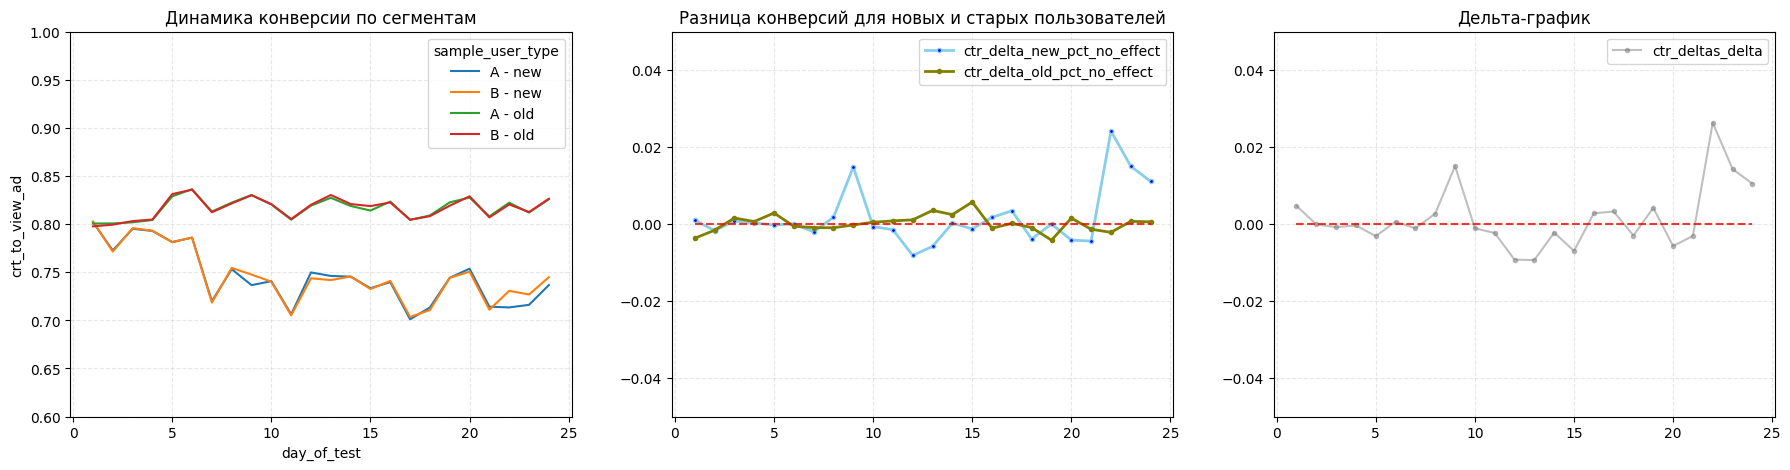

In [31]:
fig, axes = plt.subplots(1,3, figsize=(22, 5))

axes[0].set_title('Динамика конверсии по сегментам')
sns.lineplot(ax=axes[0], data=a1a2, x='day_of_test', y='crt_to_view_ad', hue='sample_user_type')
axes[0].set_ylim(0.6, 1)
axes[0].grid(True, linestyle='--', alpha=0.3)

axes[1].set_title('Разница конверсий для новых и старых пользователей')
axes[1].plot('day_of_test', 'ctr_delta_new_pct_no_effect', data=ctr_no_effect, marker='o', markerfacecolor='blue', markersize=3, color='skyblue', linewidth=2)
axes[1].plot('day_of_test', 'ctr_delta_old_pct_no_effect', data=ctr_no_effect, marker='o', markerfacecolor='olive', markersize=3, color='olive', linewidth=2)
axes[1].plot('day_of_test', np.zeros(24), data=ctr_no_effect, color='red', alpha=0.8, linestyle='--')
axes[1].set_ylim(-0.05, 0.05)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend()


axes[2].set_title('Дельта-график')
axes[2].plot('day_of_test', 'ctr_deltas_delta', data=ctr_no_effect, marker='o', markerfacecolor='grey', markersize=3, color='grey', alpha=0.5)
axes[2].plot('day_of_test', np.zeros(24), data=ctr_no_effect, color='red', alpha=0.8, linestyle='--')
axes[2].set_ylim(-0.05, 0.05)
axes[2].grid(True, linestyle='--', alpha=0.3)
axes[2].legend();


### Добавление эффекта сопротивления новому

Добавим эффект в зависимости от дня, когда пользователь присутствует в тесте - у новых пользователей максимальный негативный эффект будет в первые дни теста, но со временем он буде затухать. Если присутствует, то распространяется только на тестовую группу и только на опытных пользователей. Он выражается в снижении конверсии в просмотр в соответствии с заданной вероятностью на каждый день теста. Создадим дополнительную колонку в датасете ctr_to_view_ad_effect (новая коверсия с эффектом сопротивления новому). Она будет отражать изменение конверсии в случае, когда есть эффект сопротивления новому, заданный ранее через вероятность его возникновения.

Зададим эффект сопротивления новому, используя уравнение гиперболы от дня теста. Для пользователей, которые соответствуют условиям "старые", относятся к тестовой группе (А2) в дни, когда конверсия была, скорректируем флаг конверсии следующим образом:
1. Заведем биномиальное распределение 0 и 1, где каждое значение 1 берется в соответствии с вероятностью сопротивления новому, указанному для этого наблюдения в зависимости от дня теста. То есть для дня 1 (для пользователей, которых мы выбрали) будет 41.7% значений 1. Это распределение - есть сопротивление у пользователя в этот день или нет. Мы его не сохраняем, а передаем прямо в формуле.
2. Вычтем  из `crt_to_view_ad` (была конверсия в просмотр в этот день или нет) значение -  было сопротивление новизне или нет. В таком случае 41,7% пользователей с конверсией в просмотр в первый день теста "расконвертируются". За остальные дни соответствующая доля пользователей также "расконвертируется".

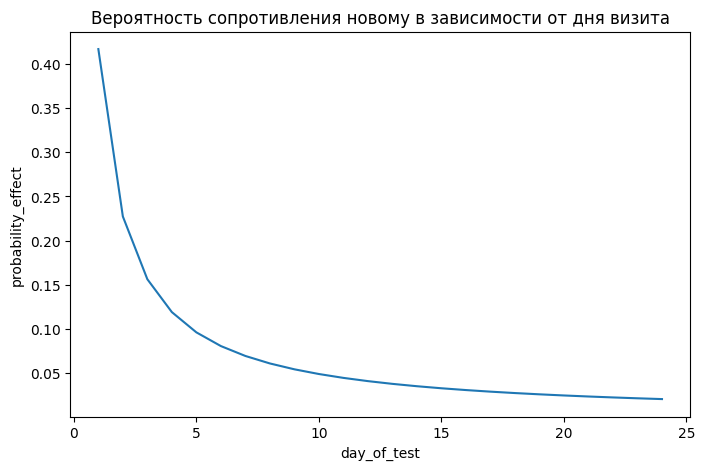

In [32]:
# параметры уравнения гипреболы
a, b = 0.5, 0.2

# вероятность эффекта сопротивления в зависимости от дня теста (максимальная вероятность сопротивления новому
# для опытных пользователей присутствует в первые дни теста, когда им требуется изменить привычный алгоритм)
primacy_prob = pd.DataFrame({'day_of_test': np.arange(1, df['day_of_test'].nunique()+1), 'probability_effect': a / (np.arange(1, df['day_of_test'].nunique()+1)+b)})

plt.figure(figsize=(8,5))
plt.title('Вероятность сопротивления новому в зависимости от дня визита')
sns.lineplot(data=primacy_prob, x='day_of_test', y='probability_effect');

In [33]:
# добавляем вероятность проявления эффекта в зависимости от дня к исходному датасету
df = df.merge(primacy_prob, how = 'left', on = 'day_of_test')
df

,first_date_in_app,date_in_app,view_ad_date,user_id,user_status,total_view_ads,crt_to_view_ad,day_of_test,sample,probability_effect
0,2023-08-01,2023-08-01,2023-08-01,qPc9vxXw2N5gt/5cYmvveel5/yI=,old,14,1,1,A,0.416667
1,2023-08-01,2023-08-01,2023-08-01,WVAkTjXnVouX5Wpi5ZdxA3sMMU8=,old,13,1,1,B,0.416667
2,2023-08-01,2023-08-01,2023-08-01,q7x7jZe8kZr91qjE2VoG5EAlz9g=,old,4,1,1,B,0.416667
3,2023-08-01,2023-08-01,2023-08-01,DPyg9nRZvqX5ZhKJg9FnLYgMFUo=,old,2,1,1,B,0.416667
4,2023-08-01,2023-08-01,2023-08-01,TiaCmyLD0IfrOf6DgpAu+wJDrgM=,old,9,1,1,A,0.416667
...,...,...,...,...,...,...,...,...,...,...
6552694,2023-08-02,2023-08-20,2023-08-20,7IL0LMVDihGRznnOY9y7u+p2qmk=,old,24,1,20,B,0.024752
6552695,2023-08-02,2023-08-22,2023-08-22,7IL0LMVDihGRznnOY9y7u+p2qmk=,old,5,1,22,B,0.022523
6552696,2023-08-02,2023-08-02,2023-08-02,7IMZ+JrS/w0hdEJd/H9bE1wmLIc=,new,1,1,2,A,0.227273
6552697,2023-08-02,2023-08-03,NaT,7IMZ+JrS/w0hdEJd/H9bE1wmLIc=,new,0,0,3,A,0.156250


In [34]:
# маска, с помощью которой отбираются пользователи, подверженные сопротивлению новому
mask = (df['user_status'] == 'old') & (df['crt_to_view_ad'] == 1) & (df['sample'] == 'B')

# df.np.random.binomial(1, df.probability_effect, len(df)) - результат 1 испытания, в котором успех (влияние нововведения) произойдет с вероятностью probability_effect
# для старых пользователей из тестовой группы убираем конверсию в просмотр рекламы
df = df.assign(ctr_to_view_ad_effec = lambda df: np.where(mask, df.crt_to_view_ad - np.random.binomial(1, df.probability_effect, len(df)), df.crt_to_view_ad))
df

,first_date_in_app,date_in_app,view_ad_date,user_id,user_status,total_view_ads,crt_to_view_ad,day_of_test,sample,probability_effect,ctr_to_view_ad_effec
0,2023-08-01,2023-08-01,2023-08-01,qPc9vxXw2N5gt/5cYmvveel5/yI=,old,14,1,1,A,0.416667,1
1,2023-08-01,2023-08-01,2023-08-01,WVAkTjXnVouX5Wpi5ZdxA3sMMU8=,old,13,1,1,B,0.416667,0
2,2023-08-01,2023-08-01,2023-08-01,q7x7jZe8kZr91qjE2VoG5EAlz9g=,old,4,1,1,B,0.416667,1
3,2023-08-01,2023-08-01,2023-08-01,DPyg9nRZvqX5ZhKJg9FnLYgMFUo=,old,2,1,1,B,0.416667,0
4,2023-08-01,2023-08-01,2023-08-01,TiaCmyLD0IfrOf6DgpAu+wJDrgM=,old,9,1,1,A,0.416667,1
...,...,...,...,...,...,...,...,...,...,...,...
6552694,2023-08-02,2023-08-20,2023-08-20,7IL0LMVDihGRznnOY9y7u+p2qmk=,old,24,1,20,B,0.024752,1
6552695,2023-08-02,2023-08-22,2023-08-22,7IL0LMVDihGRznnOY9y7u+p2qmk=,old,5,1,22,B,0.022523,1
6552696,2023-08-02,2023-08-02,2023-08-02,7IMZ+JrS/w0hdEJd/H9bE1wmLIc=,new,1,1,2,A,0.227273,1
6552697,2023-08-02,2023-08-03,NaT,7IMZ+JrS/w0hdEJd/H9bE1wmLIc=,new,0,0,3,A,0.156250,0


In [ ]:
# Средняя конверсия на пользователя изменилась, и доля сконвертировавшихся изменилась
df.groupby(['user_id','sample'], as_index=False).agg(mean_crt_to_view_ad = ('crt_to_view_ad','mean'), mean_ctr_to_view_ad_effec = ('ctr_to_view_ad_effec','mean'),
                                                          crt_to_view_ad = ('crt_to_view_ad','max'), ctr_to_view_ad_effec = ('ctr_to_view_ad_effec','max'),
                                                          count_observed = ('date_in_app','count'))\
                .groupby(['sample'], as_index=False).agg(count_users = ('user_id','count'), count_observed=('count_observed','sum'),
                                                              mean_crt_to_view_ad=('mean_crt_to_view_ad','mean'), mean_ctr_to_view_ad_effec=('mean_ctr_to_view_ad_effec','mean'),
                                                              rate_converted=('crt_to_view_ad','mean'), rate_converted_effec=('ctr_to_view_ad_effec','mean'))

,sample,count_users,count_observed,mean_crt_to_view_ad,mean_ctr_to_view_ad_effec,rate_converted,rate_converted_effec
0,A,482932,3279606,0.735756,0.735756,0.884860,0.884860
1,B,481455,3273093,0.736018,0.718520,0.884816,0.883973


### Визуализация с эффектом сопротивления новому

На графике ниже видно, как в случае опытных пользователей в тестовой группе (пользователи видят новую фичу) в первые дни снижается конверсия просмотра объявлений. По мере привыкания к нововведению, конверсия приближается к значениям, характерным для новых пользователей в тестовой группе.

В этой иллюстрации мы задали этот эффект через вероятность, в реальном тесте он будет присутствовать похожим образом (если пользователи подвержены этому эффекту).

В случае, если со временем конверсия для старых пользователей не приблизится к новым, то, скорее всего, пользователи не приняли нововведение и релиз придется откатить, даже если для новых пользователей эффект детектирован

In [44]:
ab = df.groupby(['day_of_test', 'user_status', 'sample']).agg({'ctr_to_view_ad_effec':'mean'}).reset_index()
ab['sample_effect_type'] = ab['sample'] + ' - ' + ab['user_status']
ab

,day_of_test,user_status,sample,ctr_to_view_ad_effec,sample_effect_type
0,1,new,A,0.801926,A - new
1,1,new,B,0.802769,B - new
2,1,old,A,0.800581,A - old
3,1,old,B,0.465113,B - old
4,2,new,A,0.772658,A - new
...,...,...,...,...,...
91,23,old,B,0.794977,B - old
92,24,new,A,0.736638,A - new
93,24,new,B,0.744801,B - new
94,24,old,A,0.825811,A - old


In [38]:
# Считаем изменение уровня конверсии в % отдельно для новых и старых пользователей
ctr_effect = ab.pivot(index='day_of_test', columns='sample_effect_type', values='ctr_to_view_ad_effec').reset_index()\
          .assign(ctr_delta_new_pct = lambda df: (df['B - new']-df['A - new'])/df['A - new'])\
          .assign(ctr_delta_old_pct = lambda df: (df['B - old']-df['A - old'])/df['A - old'])\
          .assign(ctr_deltas_delta = lambda x: x.ctr_delta_new_pct	- x.ctr_delta_old_pct)

ctr_effect

sample_effect_type,day_of_test,A - new,A - old,B - new,B - old,ctr_delta_new_pct,ctr_delta_old_pct,ctr_deltas_delta
0,1,0.801926,0.800581,0.802769,0.465113,0.001051,-0.419031,0.420082
1,2,0.772658,0.800680,0.771354,0.615043,-0.001688,-0.231850,0.230162
2,3,0.795125,0.801843,0.795745,0.676282,0.000780,-0.156590,0.157370
3,4,0.792879,0.804208,0.793118,0.706989,0.000302,-0.120888,0.121190
4,5,0.781361,0.828820,0.781167,0.749717,-0.000248,-0.095440,0.095191
5,6,0.785932,0.836224,0.785980,0.768690,0.000061,-0.080761,0.080822
6,7,0.719880,0.813019,0.718427,0.755885,-0.002018,-0.070273,0.068256
7,8,0.753135,0.822268,0.754464,0.771763,0.001765,-0.061422,0.063187
8,9,0.736577,0.830208,0.747522,0.784016,0.014860,-0.055638,0.070498
9,10,0.740680,0.820334,0.740211,0.780108,-0.000632,-0.049036,0.048404


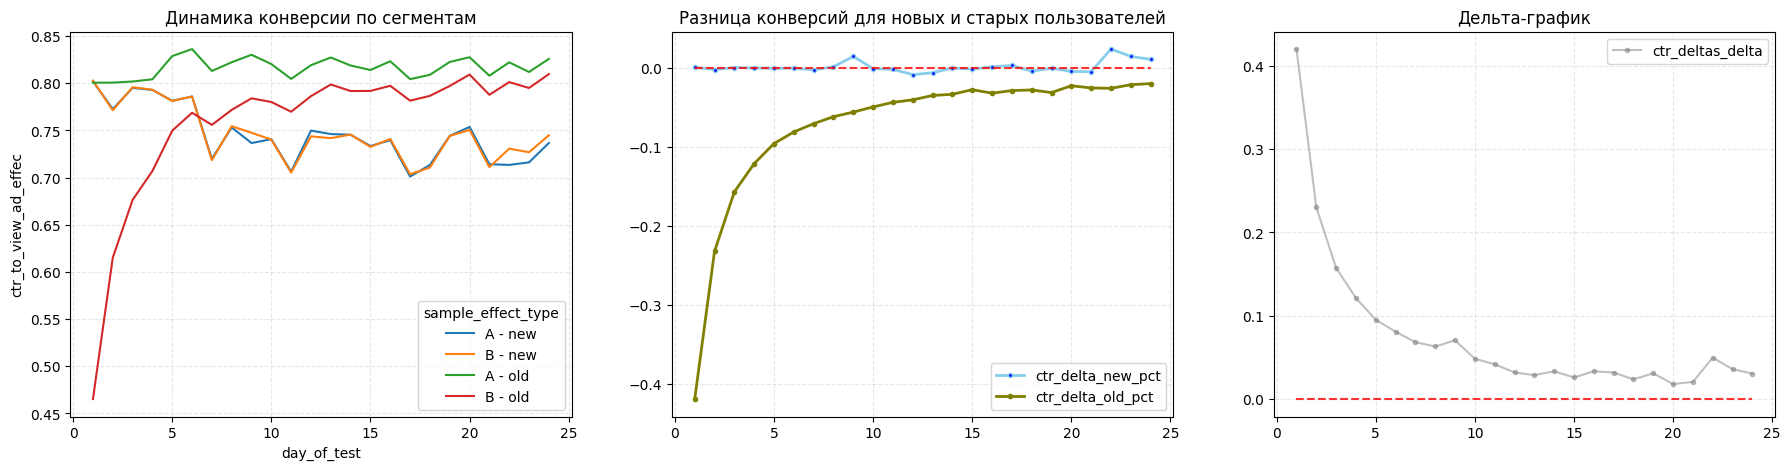

In [43]:
fig, axes = plt.subplots(1,3, figsize=(22, 5))

axes[0].set_title('Динамика конверсии по сегментам')
sns.lineplot(ax=axes[0], data=ab, x='day_of_test', y='ctr_to_view_ad_effec', hue='sample_effect_type')
axes[0].grid(True, linestyle='--', alpha=0.3)

axes[1].set_title('Разница конверсий для новых и старых пользователей')
axes[1].plot('day_of_test', 'ctr_delta_new_pct', data=ctr_effect, marker='o', markerfacecolor='blue', markersize=3, color='skyblue', linewidth=2)
axes[1].plot('day_of_test', 'ctr_delta_old_pct', data=ctr_effect, marker='o', markerfacecolor='olive', markersize=3, color='olive', linewidth=2)
axes[1].plot('day_of_test', np.zeros(24), data=ctr_effect, color='red', alpha=0.8, linestyle='--')
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend()


axes[2].set_title('Дельта-график')
axes[2].plot('day_of_test', 'ctr_deltas_delta', data=ctr_effect, marker='o', markerfacecolor='grey', markersize=3, color='grey', alpha=0.5)
axes[2].plot('day_of_test', np.zeros(24), data=ctr_effect, color='red', alpha=0.8, linestyle='--')
axes[2].grid(True, linestyle='--', alpha=0.3)
axes[2].legend();

## Эффект новизны

### Исходные данные

Попробуем имплиментировать методику LinkedIn

Подготовим синтетические данные, в которых будут наблюдения ключевой метрики (конверсии в клик) для обычных условий - когда пользователи не имеют опыта и ожиданий, и для ситуации, когда наблюдается эффект новизны:

- $\text{day_nb}$ - порядковый номер дня наблюдения
- $\text{ctr_a}$ - конверсия в клик на каждый день для контрольной группы (задается рандомно в интервале от 0 до 0.15)
- $\text{ctr_b_wo_effect}$	 - конверсия в клик на каждый день для тестовой группы (задается в интервале как и для контрольной группы)
- $\text{effect}$ - увеличение конверсии, вызванное эффектом новизны и угасающее со временем. Зададим его с помощью функции гиперболы вида $k/\text{day_nb}$, где $k$ - степень интенсивности эффекта. Например при $k=0.1$ эффект в первый день составит $\frac{\text{ctr_a}*0.1}{1}$, а на второй день $\frac{\text{ctr_a}*0.1}{2}$
- $\text{ctr_b}$ - конвесия с учетом эффекта: $\text{ctr_a}+\text{effect}$
- $\text{ctr_delta_pct}$ - относительное изменение в % между двумя группами за каждый день

In [20]:
k=0.8

data = pd.DataFrame({"date": pd.date_range(start='2023-06-01', end='2023-06-30', freq='D'), "day_nb": np.arange(1,31),
                      "ctr_a": np.random.uniform(0.1, 0.12, size=30), "ctr_b_wo_effect": np.random.uniform(0.1, 0.12, size=30)})\
        .assign(effect = lambda df: k * df['ctr_b_wo_effect'] / df['day_nb'])\
        .assign(ctr_b = lambda df: df.ctr_b_wo_effect + df.effect)\
        .assign(ctr_delta_pct = lambda df: 100 * (df.ctr_b - df.ctr_a)/df.ctr_a)

data[:10]

,date,day_nb,ctr_a,ctr_b_wo_effect,effect,ctr_b,ctr_delta_pct
0,2023-06-01,1,0.116544,0.119685,0.095748,0.215433,84.850668
1,2023-06-02,2,0.111876,0.118471,0.047388,0.165860,48.252556
2,2023-06-03,3,0.110938,0.112226,0.029927,0.142152,28.137160
3,2023-06-04,4,0.102046,0.112232,0.022446,0.134678,31.977412
4,2023-06-05,5,0.110964,0.100015,0.016002,0.116017,4.553655
5,2023-06-06,6,0.105689,0.101490,0.013532,0.115022,8.831451
6,2023-06-07,7,0.119685,0.113855,0.013012,0.126867,6.000981
7,2023-06-08,8,0.105998,0.106324,0.010632,0.116956,10.337902
8,2023-06-09,9,0.115610,0.100005,0.008889,0.108894,-5.809452
9,2023-06-10,10,0.116505,0.107729,0.008618,0.116347,-0.135764


### Получение функции новизны

Попробуем проверить, на сколько отклонение реальной метрики от ее ожидаемого значения описывается линейным трендом с заданными параметрами, для этого используем калибровочное уравнение линейной регресси, полученное в LinkedIn

- рассчитаем предикторы для модели, описывающей новизну: $d_1 = \frac{1}{\text{day_nb}^\alpha}$ и $d_2 = \frac{1}{\text{day_nb}^\gamma}$. Для $\alpha$ и $\gamma$ возьмем те же значения, что используют LinkedIn
- обучим линейную модель для предсказания относительного отклонения по значениям $d_1$ и $d_2$

In [21]:
alpha = 0.35
gamma = 2

# Рассчитаем предикторы для модели новизны
data = data.assign(d_1 = lambda df: 1 / (df['day_nb']**alpha), d_2 = lambda df: 1 / (df['day_nb']**gamma))

# использование модели линейной регрессии и получим апроксимацию эффекта новизны
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression(fit_intercept = True)
lin_reg.fit(X=data[['d_1','d_2']].values, y=data['ctr_delta_pct'].values)
data['Y_forecast'] = lin_reg.predict(X=data[['d_1','d_2']].values)

data[:10]

,date,day_nb,ctr_a,ctr_b_wo_effect,effect,ctr_b,ctr_delta_pct,d_1,d_2,Y_forecast
0,2023-06-01,1,0.116544,0.119685,0.095748,0.215433,84.850668,1.000000,1.000000,87.595566
1,2023-06-02,2,0.111876,0.118471,0.047388,0.165860,48.252556,0.784584,0.250000,37.836222
2,2023-06-03,3,0.110938,0.112226,0.029927,0.142152,28.137160,0.680781,0.111111,25.443205
3,2023-06-04,4,0.102046,0.112232,0.022446,0.134678,31.977412,0.615572,0.062500,19.669535
4,2023-06-05,5,0.110964,0.100015,0.016002,0.116017,4.553655,0.569325,0.040000,16.198260
5,2023-06-06,6,0.105689,0.101490,0.013532,0.115022,8.831451,0.534130,0.027778,13.811673
6,2023-06-07,7,0.119685,0.113855,0.013012,0.126867,6.000981,0.506076,0.020408,12.032849
7,2023-06-08,8,0.105998,0.106324,0.010632,0.116956,10.337902,0.482968,0.015625,10.634668
8,2023-06-09,9,0.115610,0.100005,0.008889,0.108894,-5.809452,0.463463,0.012346,9.493943
9,2023-06-10,10,0.116505,0.107729,0.008618,0.116347,-0.135764,0.446684,0.010000,8.537372


Посмотрим, как выглядит уравнение тренда для эффекта новизны, и насколько оно объясняет отклонения, которые мы задали. R2 достаточно высокий, но как будто бы нет полной уверенности

In [22]:
beta_0 = lin_reg.intercept_
beta_1, beta_2 = lin_reg.coef_
print(f'Тренд, описывающий эффект новизны = {beta_0:.2f} + {beta_1:.2f} * d_1 + {beta_2:.2f} * d2')
print(f"R-2 = {r2_score(data['ctr_delta_pct'], data['Y_forecast']):.2f}")

Тренд, описывающий эффект новизны = -14.20 + 49.73 * d_1 + 52.06 * d2
R-2 = 0.80


На графике
- красные точки указывают % разницы в конверсиях между группами на каждый день (правая ось),
- красная пунктирная линия - калибровочное уравнение с учетом заданных коэффициентов альфа и гамма (правая ось)
- голубая и зеленая линии - конверсии для контрольной и тестовой групп.

Чем ближе расположение красных точек к линии калибровочного уравнения - тем выше шанс, что эффект будет отнесен к эффекту новизны. Важно учитывать монотонность изменений конверсий. Монотонное снижение % разницы в конверсиях заложено в калибровочное уравнение. Немонотонное изменение реальных данных приведет к ухудшению описания реальных данных калибровочным уравнением и понизит R2, хотя эффект новизны, возможно, и будет присутствовать.

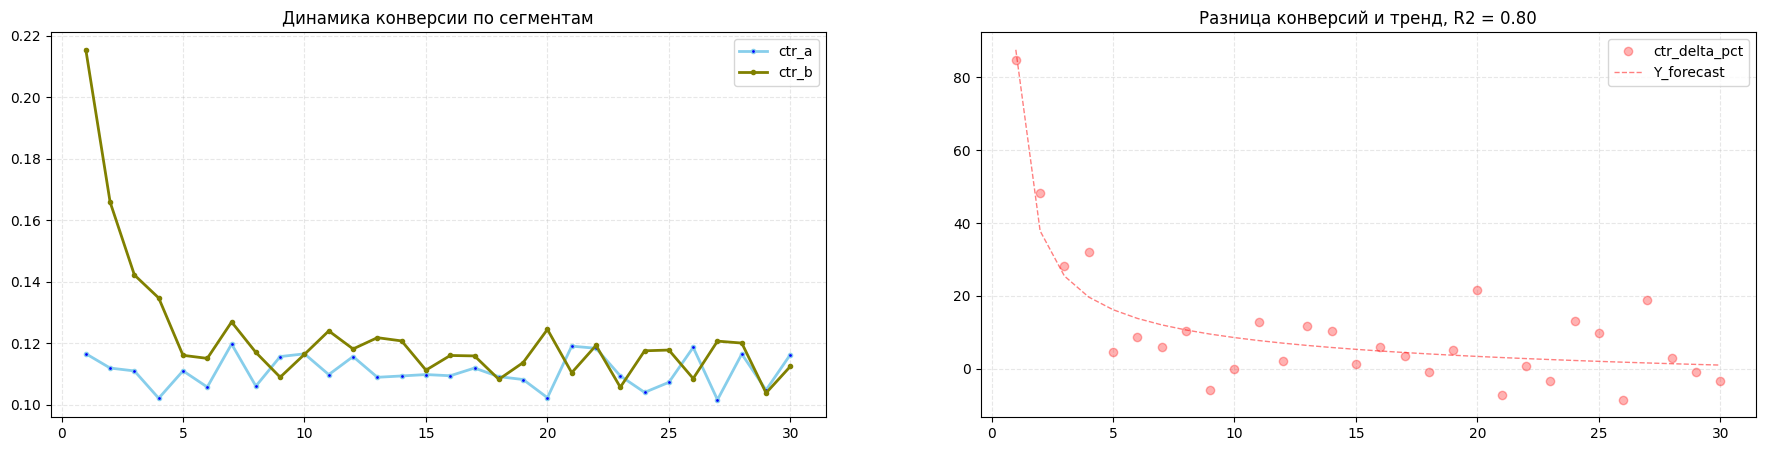

In [23]:
fig, axes = plt.subplots(1,2, figsize=(22, 5))

axes[0].set_title('Динамика конверсии по сегментам')
axes[0].plot('day_nb', 'ctr_a', data=data, marker='o', markerfacecolor='blue', markersize=3, color='skyblue', linewidth=2)
axes[0].plot('day_nb', 'ctr_b', data=data, marker='o', markerfacecolor='olive', markersize=3, color='olive', linewidth=2)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].legend()

axes[1].set_title(f"Разница конверсий и тренд, R2 = {r2_score(data['ctr_delta_pct'], data['Y_forecast']):.2f}")
axes[1].plot('day_nb', 'ctr_delta_pct', data=data, marker='o', color='red', linewidth=0, alpha=0.3)
axes[1].plot('day_nb', 'Y_forecast', data=data, marker='', color='red', linewidth=1, linestyle='--', alpha=0.5)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend();

### Симуляция детекции эффекта

Проведем по 100 раз генерацию данных и проверку на наличие эффекта новизны для каждого уровня интенсивности от 0 до 3 с шагом 0.1 и посмотрим, начиная с какого уровня интенсивности критерий $R^2$ покажет наличие влияния эффект новизны

Как видно по результатам симуляции, если в качестве порогового значения мы выбираем $R^2=0.8$, то с вероятностью 95% будем детектировать эффект новизны при $k>=1.1$, т.е. если превышение ключевой метрики за счет новизны составит 110% и более. Если значение ниже - мы можем пропустить эффект, что говорит о недостаточной чувствительности теста. Можно понизить пороговое значение $R^2$ или поработать над степенными коэффициентами. Впрочем, никто нам не мешает изобрести свой критерий, основываясь на своих данных

In [24]:
alpha = 0.35
gamma = 2
tests_number = 100
result = []
k_list = np.arange(0., 3.1, 0.1)

for k in k_list:
    r2_list = []
    for _ in range(tests_number):
        data = pd.DataFrame({"date": pd.date_range(start='2023-06-01', end='2023-06-30', freq='D'), "day_nb": np.arange(1,31),
                              "ctr_a": np.random.uniform(0.1, 0.12, size=30), "ctr_b_wo_effect": np.random.uniform(0.1, 0.12, size=30)})\
                .assign(effect = lambda df: k * df['ctr_b_wo_effect'] / df['day_nb'])\
                .assign(ctr_b = lambda df: df.ctr_b_wo_effect + df.effect)\
                .assign(ctr_delta_pct = lambda df: 100 * (df.ctr_b - df.ctr_a)/df.ctr_a)

        data = data.assign(d_1 = lambda df: 1 / (df['day_nb']**alpha), d_2 = lambda df: 1 / (df['day_nb']**gamma))

        # построим модель линейной регрессии
        lin_reg = LinearRegression(fit_intercept = True)
        lin_reg.fit(X=data[['d_1','d_2']].values, y=data['ctr_delta_pct'].values)
        data['Y_forecast'] = lin_reg.predict(X=data[['d_1','d_2']].values)

        r2_list.append(r2_score(data['ctr_delta_pct'], data['Y_forecast']))

    r2_median, c2_ci_low, r2_ci_upper = np.quantile(r2_list, 0.5), np.quantile(r2_list, 0.025), np.quantile(r2_list, 0.975)
    result.append([k, r2_median, c2_ci_low, r2_ci_upper])

result_df = pd.DataFrame(result, columns=['k', 'r2', 'CI_2.5', 'CI_97.5'])

In [25]:
result_df.iloc[np.arange(0,35,5),:]

,k,r2,CI_2.5,CI_97.5
0,0.0,0.052978,0.003027,0.213536
5,0.5,0.618731,0.391075,0.805995
10,1.0,0.858386,0.772698,0.913574
15,1.5,0.921217,0.871847,0.963295
20,2.0,0.946261,0.904969,0.971402
25,2.5,0.962912,0.927760,0.981664
30,3.0,0.970497,0.941994,0.984416


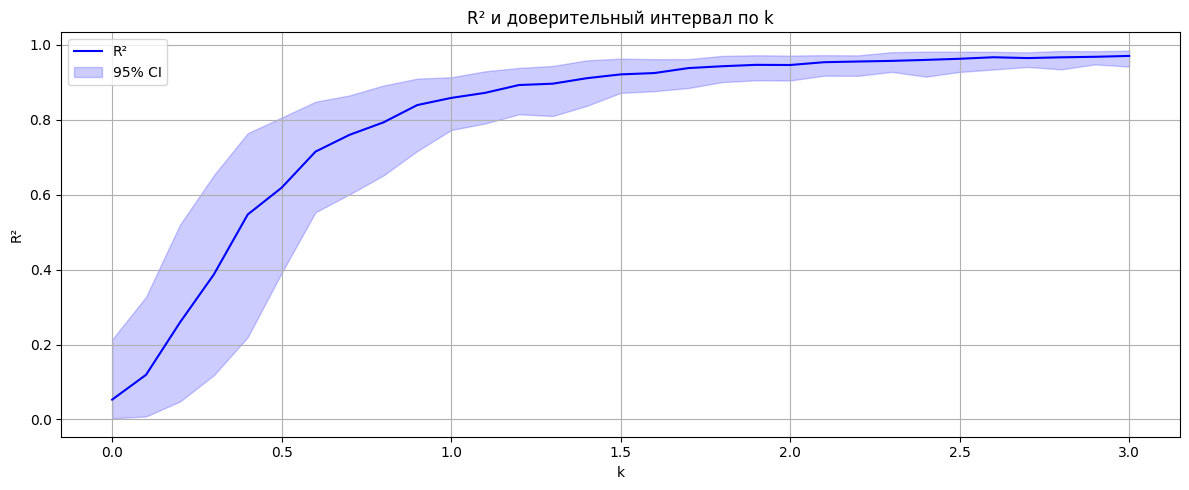

In [26]:
# Построение графика
plt.figure(figsize=(12, 5))
plt.plot(result_df['k'], result_df['r2'], label='R²', color='blue')
plt.fill_between(result_df['k'], result_df['CI_2.5'], result_df['CI_97.5'], color='blue', alpha=0.2, label='95% CI')
plt.xlabel('k')
plt.ylabel('R²')
plt.title('R² и доверительный интервал по k')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Практика на реальных данных

## Эффект сопротивления новому

### **СПЕЦИФИКАЦИЯ**

**Бизнес-предпосылки**: с целью защиты контактных данных от парсеров командой дискавери предложено закрывать форму контактов капчей, что должер снизить долю парсеров. Однако есть предположение, что капча снизит уровень конверсии в контакт, но важно понимать - насколько продолжительным и интенсивным будет это снижение

**Задача**: провести эксперимент и выяснить, сколько составит снижение конверсии в контакт и увидем ли мы в хлде эксперимента эффект сопротивления новому

**Решение**: чтобы детектировать эффект сопротивление новому нужно разделить пользователей на новых и старых, и проследить изменение метрики по дням.
1. В каждой из групп - тестовой и контрольной  - выделим старых и новых пользователей
2. Агрегируем метрику за каждый день эксперимента
3. Сравним динамику метрики для новых и старых в контрольной группе и для новых и старых в тестовой группе
4. Построим график самой метрики в разрезе сегментов по дням и разницы метрики для старых и новых пользователей

**Данные**:
таблица сагрегирована на пользователя (user_id) и день (date_in_app) и показывает всех, кто был активен в этот день и была ли у них конверсия в контакт (conv_to_contact_daily)
- `user_id` - id - пользователя
- `sample_type` - тип выборки
- `date_in_app` - день пользователя, когда он был в приложении
- `first_date_in_app` - первый день, когда пользователь пришел в приложение
- `day_of_test` - порядковый номер дня проведения теста
- `conv_to_contact_daily` - итоговая конверсия в контакт для пользователя на этот день (date_in_app)

In [45]:
df = pd.read_csv('data_for_primacy effect_2.csv')
df

,user_id,sample_type,date_in_app,first_date_in_app,day_of_test,conv_to_contact_daily
0,00018D9EB5E146AA8B578E427AEC323A,A,2023-07-02,2023-07-02,22,0
1,00018D9EB5E146AA8B578E427AEC323A,A,2023-07-06,2023-07-02,26,0
2,00018D9EB5E146AA8B578E427AEC323A,A,2023-07-08,2023-07-02,28,0
3,00018D9EB5E146AA8B578E427AEC323A,A,2023-07-09,2023-07-02,29,0
4,00027C4F85D64F4A81E95ECCCA1634FE,B,2023-06-14,2023-06-14,4,0
...,...,...,...,...,...,...
713951,FFFE37BB811E410F9617079E4F74CB8A,A,2023-07-04,2023-06-28,24,1
713952,FFFE37BB811E410F9617079E4F74CB8A,A,2023-07-03,2023-06-28,23,1
713953,FFFE37BB811E410F9617079E4F74CB8A,A,2023-07-05,2023-06-28,25,1
713954,FFFE37BB811E410F9617079E4F74CB8A,A,2023-07-08,2023-06-28,28,1


In [46]:
# Преобразуем даты
df['date_in_app'] = pd.to_datetime(df['date_in_app'])
df['first_date_in_app'] = pd.to_datetime(df['first_date_in_app'])

### Первичный тест

Посмотрим, на сколько изменилась конверсия, и проверим значимость изменений с помощью z-теста на пропорцию

In [ ]:
agg_df = df.groupby(['user_id','sample_type'], as_index=False).agg({'conv_to_contact_daily':'max'})\
          .groupby('sample_type', as_index=False).agg(is_conv = ('conv_to_contact_daily','sum'), total_users = ('user_id','count'))\
                  .assign(conv_rate = lambda x: x.is_conv/x.total_users)

agg_df

,sample_type,is_conv,total_users,conv_rate
0,A,42833,48750,0.878626
1,B,41762,48291,0.864799


In [ ]:
print(f'Снижение конверсии в тестовой группе = {agg_df.conv_rate[0]-agg_df.conv_rate[1]:.2%}')

_, p_value = proportions_ztest(agg_df.is_conv, agg_df.total_users)
print(f'H0: конверсия в контрольной группе не изменилась \np-value = {p_value:.3f}')
if p_value<0.05:
    print('p-value < 0.05 => oтклоняем H0')
else:
    print('p-value >= 0.05 => не отклоняем H0')

Снижение конверсии в тестовой группе = 1.38%
H0: конверсия в контрольной группе не изменилась 
p-value = 0.000
p-value < 0.05 => oтклоняем H0


### Подготовка данных

Для выявления эффекта сопротивления новому разметим всех пользователей на новых и старых: пользователи, пришедшие 3 и более суток назад будут отнесены к новым, 2-е суток и менее - к новым. Таким образом получим 4 сегмента:
- новые пользователи — группа А
- новые пользователи — группа B
- старые пользователи — группа А
- старые пользователи — группа B

Также определим номер дня для каждого пользователя на каждый день эксперимента, начиная с первого дня пользователя в приложении (`retention_day`)

Для каждой из 4-х полученных сегментов агрегируем уровень конверсии `ctr`на каждый день эксперимента

In [47]:
agg_per_date = (
    # Расчитываем возраст пользователя в днях
    df.assign(date_from_start = lambda df: (df['date_in_app'] - df['first_date_in_app']).dt.days.astype('int'))
    # Кодируем пользователя - если он 2 или меньше дней в приложении - новый, иначе - старый
    .assign(user_status = lambda df: np.where(df.date_from_start<=2,"new","old"))
    # Группируем по дням теста и объединяем разметки по признакам новый/старый контроль/тест в 1 признак
    .groupby(['day_of_test','sample_type','user_status'], as_index=False).agg(num_converted = ('conv_to_contact_daily','sum'), total_users = ('user_id','count'))
    # Рассчитываем уровень конверсии для каждого дня теста и каждой из 4-х групп
    .assign(sample_user_type = lambda x: x.sample_type+'-'+x.user_status).assign(ctr = lambda x: x.num_converted/x.total_users))

agg_per_date

,day_of_test,sample_type,user_status,num_converted,total_users,sample_user_type,ctr
0,0,A,new,230,312,A-new,0.737179
1,0,A,old,8419,10513,A-old,0.800818
2,0,B,new,259,332,B-new,0.780120
3,0,B,old,3659,10296,B-old,0.355381
4,1,A,new,238,325,A-new,0.732308
...,...,...,...,...,...,...,...
115,28,B,old,8746,10976,B-old,0.796829
116,29,A,new,241,331,A-new,0.728097
117,29,A,old,9395,11342,A-old,0.828337
118,29,B,new,243,312,B-new,0.778846


### Детекция эффекта

Сравнивая динамику конверсии в контакт на графике мы видим, что для новых пользователей из тестовой группы конверсия в начале эксперимента снизилась в 2 раза, но со временем вернулась к обычному уровню


Рассчитаем разницу в изменениях для старых и новых пользователей в тестовой (В) и контрольной (А) группах и также визуализируем на графике. Видим, что если для контрольной группы конверсия в контакт выше у новых пользователей, то для тестовой группы конверсия для новых пользователей снизилась в первые дни эксперимента на 6 п.п. Однако снижение имеет не продолжнительный характер, на 15-й день разница исчезает

In [48]:
df_deltas = agg_per_date.pivot(index='day_of_test', columns='sample_user_type', values='ctr').reset_index()\
          .assign(ctr_delta_new = lambda df: (df['B-new']-df['A-new'])/df['A-new'])\
          .assign(ctr_delta_old = lambda df: (df['B-old']-df['A-old'])/df['A-old'])\
          .assign(ctr_deltas_delta = lambda x: x.ctr_delta_new-x.ctr_delta_old)

df_deltas

sample_user_type,day_of_test,A-new,A-old,B-new,B-old,ctr_delta_new,ctr_delta_old,ctr_deltas_delta
0,0,0.737179,0.800818,0.780120,0.355381,0.058250,-0.556228,0.614478
1,1,0.732308,0.776104,0.760797,0.547733,0.038904,-0.294253,0.333157
2,2,0.782369,0.810289,0.800000,0.652883,0.022535,-0.194259,0.216795
3,3,0.742500,0.793848,0.749271,0.666943,0.009119,-0.159860,0.168980
4,4,0.786325,0.821354,0.786885,0.721421,0.000713,-0.121668,0.122381
5,5,0.723861,0.779166,0.775281,0.713795,0.071036,-0.083898,0.154935
6,6,0.773885,0.776071,0.769231,0.724132,-0.006015,-0.066926,0.060912
7,7,0.762611,0.785058,0.784768,0.734836,0.029054,-0.063972,0.093026
8,8,0.771014,0.793592,0.785276,0.742510,0.018497,-0.064369,0.082866
9,9,0.734463,0.822057,0.752089,0.768267,0.023998,-0.065434,0.089432


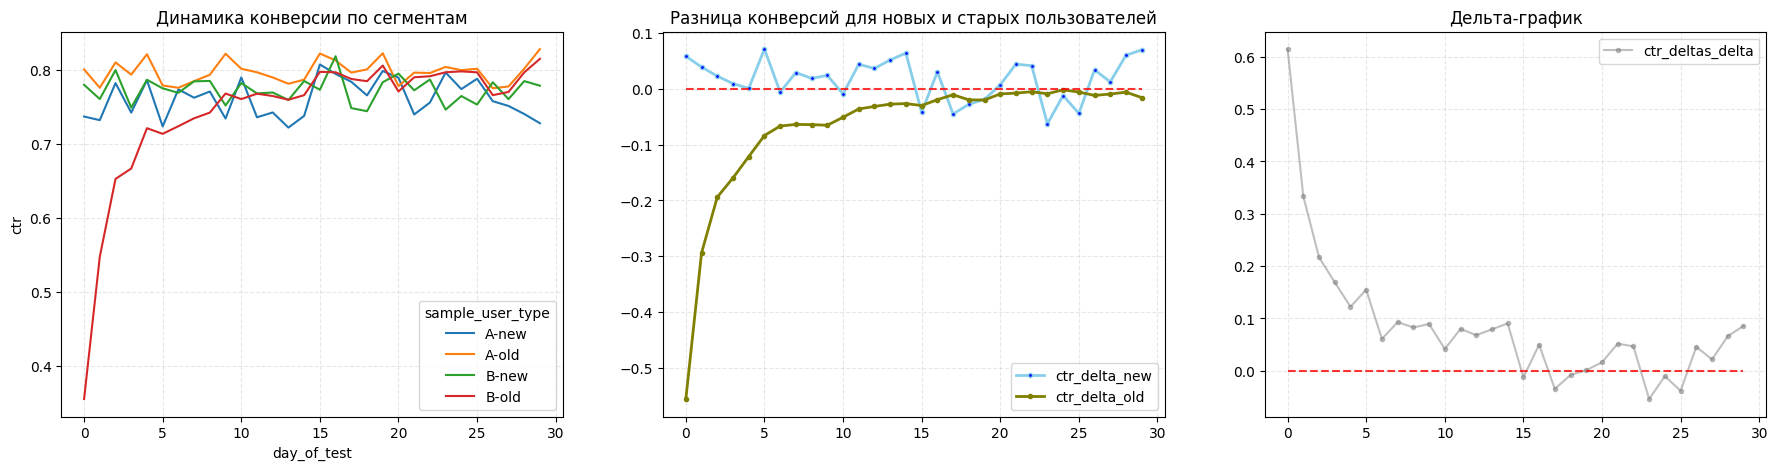

In [51]:
fig, axes = plt.subplots(1,3, figsize=(22, 5))

axes[0].set_title('Динамика конверсии по сегментам')
sns.lineplot(ax=axes[0], data=agg_per_date, x='day_of_test', y='ctr', hue='sample_user_type')
axes[0].grid(True, linestyle='--', alpha=0.3)

axes[1].set_title('Разница конверсий для новых и старых пользователей')
axes[1].plot('day_of_test', 'ctr_delta_new', data=df_deltas, marker='o', markerfacecolor='blue', markersize=3, color='skyblue', linewidth=2)
axes[1].plot('day_of_test', 'ctr_delta_old', data=df_deltas, marker='o', markerfacecolor='olive', markersize=3, color='olive', linewidth=2)
axes[1].plot('day_of_test', np.zeros(30), data=df_deltas, color='red', alpha=0.8, linestyle='--')
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend()


axes[2].set_title('Дельта-график')
axes[2].plot('day_of_test', 'ctr_deltas_delta', data=df_deltas, marker='o', markerfacecolor='grey', markersize=3, color='grey', alpha=0.5)
axes[2].plot('day_of_test', np.zeros(30), data=df_deltas, color='red', alpha=0.8, linestyle='--')
axes[2].grid(True, linestyle='--', alpha=0.3)
axes[2].legend();

## Эффект новизны

### **СПЕЦИФИКАЦИЯ**

**Бизнес-предпосылки**: Менеджеры с ML-командой придумали новый алгоритм поисковой выдачи в автоклассифайде. Алгоритм сложный, требующий дополнительных расходов на поддержание и внедрение в продакшн. Для того, чтобы понять, стоит ли игра свеч, команда решила протестировать MVP-вариант. В прод запустили параллельного ранжировщика, который ранжирует поисковую выдачу только в тестовой группе В, и раскатили это через А/Б-тест. Менеджеры считают, что уровень практической значимости = + 4 п.п. (с текущих 16% до 20%). Согласно юнит-экономике, такой прирост даст достаточный прирост покупателей в продукте и повысит эффективность платных услуг.

**Задача**: провести тест и определить, есть ли статистически значимый прирост метрики. Но нужно быть осторожным, т.к. есть риски траты серьезных ресурсов команды. Поэтому дополнительно нужно проверить результаты теста на предмет присутствия эффекта новизны.

**Ход исследования** Для детекции эффекта новизны будем использовать тот же алгоритм команды Linkedin.
1. Построим агрегированную таблицу по дням теста с конверсией в группе А и группе В
2. Найдем разницу в конверсиях (delta) - target в линейной регрессии
3. Построим график и визуально проверим, есть ли эффект новизны в данных
4. Расчитаем предикторы для тренда эффекта новизны на основе $\alpha$ и $\gamma$
5. Обучим линейную регрессию и построим апроксимацию разницы конверсий в линейный тренд
6. Рассчитаем R2

**Данные**: таблица с данными о конверсии пользователей в просмотр контакта за каждый день теста и датой первого посещения приложения

Схема таблицы:

- `user_id`  — id пользователя
- `date_in_app`  — день участия в тесте
- `total_contacts`  — суммарное количество контактов, сделанных пользователем в конкретный день (date_in_app)
- `first_date_in_app`  — первый день появления в приложении
- `day_of_test`  — порядковый день проведения теста
- `sample_type`  — тип группы в эксперименте
- `conv_to_contact`  — была ли конверсия в конкретный день теста (date_in_app)

In [4]:
df = pd.read_csv('novelty_effect.csv')
df

,user_id,sample_type,date_in_app,total_contacts,first_date_in_app,day_of_test,conv_to_contact_daily
0,000015E6362C47CFBA851EA91D417F8B,A,2023-06-10,1.0,2023-01-12,0,1
1,000015E6362C47CFBA851EA91D417F8B,A,2023-06-29,5.0,2023-01-12,19,1
2,0000FF6D0FAE419384034F249C4DC10B,B,2023-06-22,1.0,2023-01-02,12,1
3,0000FF6D0FAE419384034F249C4DC10B,B,2023-06-18,10.0,2023-01-02,8,1
4,00028A57EC044DA2ADD1F07F93296838,A,2023-07-04,1.0,2023-01-16,24,1
...,...,...,...,...,...,...,...
855677,FFFEF3D68226457AB8AEDA3145394370,B,2023-06-23,6.0,2023-01-02,13,1
855678,FFFEF3D68226457AB8AEDA3145394370,B,2023-06-24,NaN,2023-01-02,14,0
855679,FFFF53FED90942A8B9848507AFC86DA3,B,2023-06-12,19.0,2023-02-15,2,1
855680,FFFFC2B7BC7B47D99824B292CAB6E4E2,A,2023-07-02,NaN,2023-01-01,22,0


### Первичный тест

In [5]:
ctr_ab = df.groupby(['user_id','sample_type'], as_index=False).agg({'conv_to_contact_daily':'max'})\
      .groupby('sample_type', as_index=False).agg({'conv_to_contact_daily':'sum','user_id':'count'})\
      .rename(columns={'user_id':'total_users','conv_to_contact_daily':'num_converted'})\
      .assign(ctr_to_contact = lambda x: x.num_converted/x.total_users).set_index('sample_type')
ctr_ab

,num_converted,total_users,ctr_to_contact
sample_type,,,
A,51403,58323,0.881350
B,52171,58459,0.892437


In [9]:
print(f"Увеличение конверсии в тестовой группе = {ctr_ab.ctr_to_contact['B']:.2%} - {ctr_ab.ctr_to_contact['A']:.2%} = {ctr_ab.ctr_to_contact['B']-ctr_ab.ctr_to_contact['A']:.2%}")

_, p_value = proportions_ztest(ctr_ab.num_converted, ctr_ab.total_users)
print(f'H0: конверсия в контрольной группе не изменилась \np-value = {p_value:.3f}')
if p_value<0.05:
    print('p-value < 0.05 => oтклоняем H0')
else:
    print('p-value >= 0.05 => не отклоняем H0')

Увеличение конверсии в тестовой группе = 89.24% - 88.14% = 1.11%
H0: конверсия в контрольной группе не изменилась 
p-value = 0.000
p-value < 0.05 => oтклоняем H0


### Детекция эффекта
График и $R^2>0.8$ показывают присутствие эффекта новизны

In [11]:
alpha = 0.35
gamma = 2

agg_per_day = (
            # Перенумеруем дни теста, чтобы начинались от 1, а не от 0
            df.assign(day_of_test = lambda x: x.day_of_test+1)
            .pivot_table(index='day_of_test', columns='sample_type', values='conv_to_contact_daily').reset_index()
            # рассчитаем относительное изменение конверсии в тестовой группе
            .assign(ctr_delta_pct = lambda x: ((x.B-x.A)/x.A)*100)
            # Рассчитаем предикторы для модели новизны
            .assign(d_1 = lambda x: 1/(x.day_of_test**alpha)).assign(d_2 = lambda x: 1/(x.day_of_test**gamma)))

# использование модели линейной регрессии и получим апроксимацию эффекта новизны
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression(fit_intercept = True)
lin_reg.fit(X=agg_per_day[['d_1','d_2']].values, y=agg_per_day['ctr_delta_pct'].values)
agg_per_day['Y_forecast'] = lin_reg.predict(X=agg_per_day[['d_1','d_2']].values)

agg_per_day

sample_type,day_of_test,A,B,ctr_delta_pct,d_1,d_2,Y_forecast
0,1,0.801359,0.913524,13.996958,1.000000,1.000000,14.419114
1,2,0.774500,0.849515,9.685568,0.784584,0.250000,7.449346
2,3,0.812389,0.850587,4.701899,0.680781,0.111111,5.347099
3,4,0.789817,0.821426,4.002024,0.615572,0.062500,4.244617
4,5,0.811692,0.832643,2.581185,0.569325,0.040000,3.530338
5,6,0.781839,0.802654,2.662246,0.534130,0.027778,3.014420
6,7,0.771529,0.796097,3.184315,0.506076,0.020408,2.616578
7,8,0.786402,0.802465,2.042660,0.482968,0.015625,2.296148
8,9,0.799501,0.810300,1.350664,0.463463,0.012346,2.029956
9,10,0.809109,0.830217,2.608727,0.446684,0.010000,1.803645


In [12]:
beta_0 = lin_reg.intercept_
beta_1, beta_2 = lin_reg.coef_
print(f'Тренд, описывающий эффект новизны = {beta_0:.2f} + {beta_1:.2f} * d_1 + {beta_2:.2f} * d2')
print(f"R-2 = {r2_score(agg_per_day['ctr_delta_pct'], agg_per_day['Y_forecast']):.2f}")

Тренд, описывающий эффект новизны = -3.92 + 12.70 * d_1 + 5.65 * d2
R-2 = 0.95


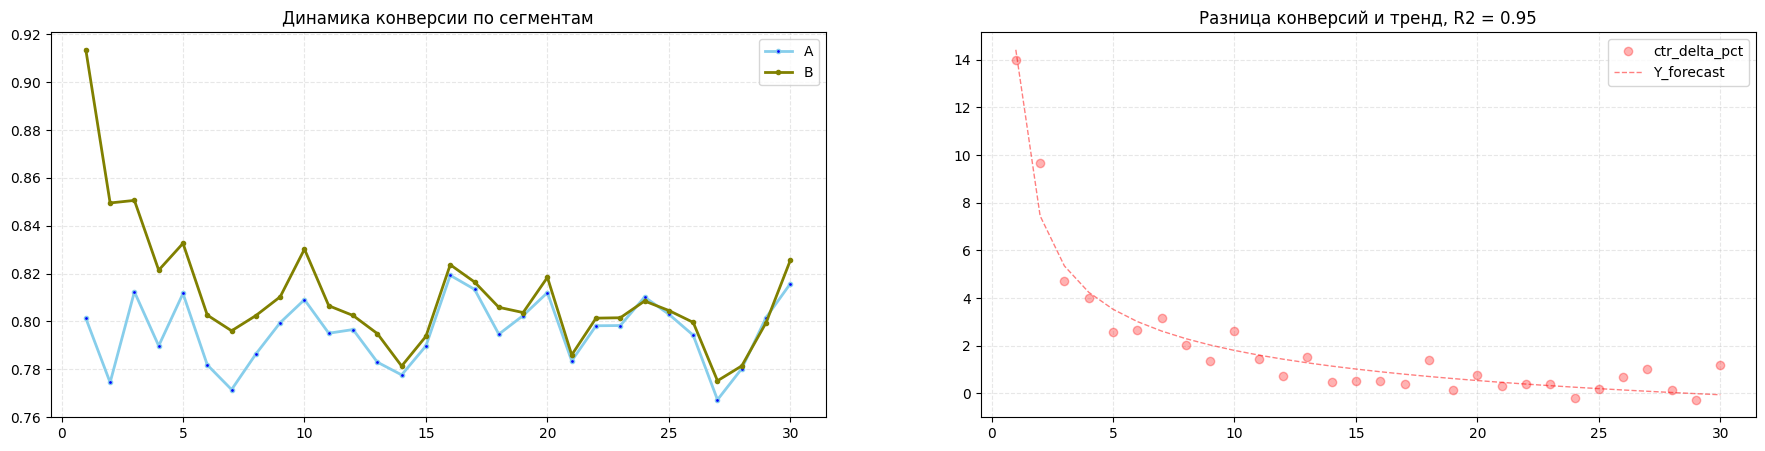

In [19]:
fig, axes = plt.subplots(1,2, figsize=(22, 5))

axes[0].set_title('Динамика конверсии по сегментам')
axes[0].plot('day_of_test', 'A', data=agg_per_day, marker='o', markerfacecolor='blue', markersize=3, color='skyblue', linewidth=2)
axes[0].plot('day_of_test', 'B', data=agg_per_day, marker='o', markerfacecolor='olive', markersize=3, color='olive', linewidth=2)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].legend()

axes[1].set_title(f"Разница конверсий и тренд, R2 = {r2_score(agg_per_day['ctr_delta_pct'], agg_per_day['Y_forecast']):.2f}")
axes[1].plot('day_of_test', 'ctr_delta_pct', data=agg_per_day, marker='o', color='red', linewidth=0, alpha=0.3)
axes[1].plot('day_of_test', 'Y_forecast', data=agg_per_day, marker='', color='red', linewidth=1, linestyle='--', alpha=0.5)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend();